# Example 1 (Dubins) — publication figures

Three methods (Vanilla MPC, Unconstrained reach-avoid, RA-MPC ours), one
**stacked figure per method**: closed-loop success scatter on top, control
signals below. Every scatter overlays ONE sample trajectory from a **shared**
$x_0$ (successful under all three). Control panels overlay RA-MPC vs the
unconstrained controller per channel. Style follows `notebooks/`.

Reuses cached sweep success (Vanilla, RA-MPC at the baseline $T_s$); the
unconstrained closed-form success is computed here (cached to CSV). Needs
casadi + scipy + sympy (env `rab_mpc`).


## §0 — Imports, paths, palette


In [87]:
import importlib.util, json, os, warnings
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
from scipy.integrate import solve_ivp

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
CTRL = os.path.join(REV, "controllers")
REV_DATA = os.path.join(REV, "data")

import sys as _sys

_pp = os.path.join(ROOT, "python")
if _pp not in _sys.path:
    _sys.path.insert(0, _pp)
from functional import (
    BetterColor,
)  # gray0/orange3/green0 palette (matches the example notebooks)

BASE_DT = 0.05
N_HOR_BASE = 25
PHI_TOL = 0.05
T_MAX = 10.0
T_MAX_UNCON = 40.0
TARGET_POS = np.array([-1.7, 0.0])
FS = 26
# palette (matches notebooks/)
C_SAFE = "#b2182b"
C_TARGET = "#d6604d"
C_SUCC = "#2166ac"
C_FAIL = "#d73027"
C_START = (1.0, 0.549, 0.0)
C_END = (0.102, 0.596, 0.314)  # orange3, green0
C_UNCON = "#2166ac"
C_PROP = "#8856a7"
C_BOUND = "#636363"  # control colors
print("ROOT:", ROOT)

ROOT: /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC


## §1 — Controllers (RA-MPC cert + bounds, unconstrained law), sets


In [88]:
with open(os.path.join(REV_DATA, "phase1_3_meta_dubins.json")) as fh:
    meta = json.load(fh)
U_MAX = [float(meta["u_max_eff"]["omega"]), float(meta["u_max_eff"]["a"])]
u1_max, u2_max = U_MAX

x1, x2, th, v = sp.symbols("x1 x2 th v")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, th, v]
hx = sp.Matrix([x1, x2])
h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
target_y = (y2) ** 2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4
safe_y = 1e-3 * (-target_y + 300) * h_raw
safe_x = safe_y.subs({y1: hx[0], y2: hx[1]})
target_x = target_y.subs({y1: hx[0], y2: hx[1]})
safe_x_f = sp.lambdify(state_vars, safe_x, "numpy")
target_x_f = sp.lambdify(state_vars, target_x, "numpy")
safe_y_f = sp.lambdify([y1, y2], safe_y, "numpy")
target_y_f = sp.lambdify([y1, y2], target_y, "numpy")
hx_f = sp.lambdify(state_vars, hx, "numpy")


def _load(p):
    spec = importlib.util.spec_from_file_location(os.path.basename(p)[:-3], p)
    m = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(m)
    return m


ra_mod = _load(os.path.join(CTRL, "dubins_constrained.py"))
cert = sp.sympify(ra_mod.certificate_opt)
unc_mod = _load(os.path.join(CTRL, "dubins_unconstrained.py"))
u_unc = [sp.lambdify(state_vars, ui, "numpy") for ui in sp.Matrix(unc_mod.u_opt)]


def u_unc_of(x):
    return np.array([float(np.squeeze(f(*x))) for f in u_unc])


print("u_max_eff =", U_MAX)

u_max_eff = [7.7, 5.1]


## §2 — Candidate set (seed 42) + cached sweep success (Vanilla, RA-MPC)


In [89]:
np.random.seed(42)
lb_box = np.array([-2.0, -2.0, 2 * np.pi / 3, -1.0])
ub_box = np.array([2.0, 2.0, 4 * np.pi / 3, 1.0])
x_pool = np.random.rand(4, 1000) * (ub_box - lb_box).reshape(-1, 1) + lb_box.reshape(
    -1, 1
)
cand_idx = np.where(
    (np.atleast_1d(np.squeeze(safe_x_f(*x_pool))) >= 0)
    & (np.atleast_1d(np.squeeze(target_x_f(*x_pool))) > 0)
)[0][:300]
x_cands = x_pool[:, cand_idx]
Ncand = x_cands.shape[1]
Y0 = np.array(hx_f(*x_cands)).reshape(2, -1)

raw = pd.read_csv(os.path.join(REV_DATA, "dubins_sweep_raw.csv"))


def _mask(method):
    s = raw[(raw.method == method) & (np.isclose(raw.dt_mpc, BASE_DT))].sort_values(
        "cand_id"
    )
    return s["success"].values.astype(bool)


succ = {"Vanilla MPC": _mask("Vanilla MPC"), "RA-MPC (ours)": _mask("RA-MPC (ours)")}
print(
    "from sweep CSV @ dt=%.3f:  Vanilla %d/%d,  RA-MPC %d/%d"
    % (BASE_DT, succ["Vanilla MPC"].sum(), Ncand, succ["RA-MPC (ours)"].sum(), Ncand)
)

from sweep CSV @ dt=0.050:  Vanilla 241/300,  RA-MPC 251/300


## §3 — Unconstrained closed-form closed-loop success (computed + cached)


In [90]:
UNC_CSV = os.path.join(REV_DATA, "dubins_uncon_success.csv")
REGEN_UNC = False


def uncon_rollout(x0, t_max=T_MAX_UNCON):
    def rhs(t, x):
        u = u_unc_of(x)
        d = np.array([x[3] * np.cos(x[2]), x[3] * np.sin(x[2]), u[0], u[1]])
        return d if np.all(np.isfinite(d)) else np.zeros(4)

    def ev(t, x):
        return float(np.squeeze(target_x_f(*x)))

    ev.terminal = True
    ev.direction = -1
    s = solve_ivp(
        rhs,
        (0, t_max),
        np.asarray(x0, float),
        method="DOP853",
        events=ev,
        rtol=1e-8,
        atol=1e-10,
        max_step=BASE_DT,
        dense_output=True,
    )
    reached = s.status == 1
    if not np.all(np.isfinite(s.y)):
        return False
    ts = np.linspace(0, s.t[-1], max(2, int(s.t[-1] / (BASE_DT / 10)) + 1))
    xs = s.sol(ts)
    safe = bool(np.all(np.atleast_1d(np.squeeze(safe_x_f(*xs))) >= 0))
    return bool(reached and safe)


if (not REGEN_UNC) and os.path.exists(UNC_CSV):
    um = pd.read_csv(UNC_CSV)
    if len(um) == Ncand and int(um["seed"].iloc[0]) == 42:
        succ["Uncon. reach-avoid"] = um["success"].values.astype(bool)
        print(
            "loaded cached unconstrained success:",
            succ["Uncon. reach-avoid"].sum(),
            "/",
            Ncand,
        )
if "Uncon. reach-avoid" not in succ:
    import time

    t0 = time.time()
    m = np.array([uncon_rollout(x_cands[:, i]) for i in range(Ncand)])
    pd.DataFrame({"cand_id": np.arange(Ncand), "success": m, "seed": 42}).to_csv(
        UNC_CSV, index=False
    )
    succ["Uncon. reach-avoid"] = m
    print(
        "computed unconstrained success: %d/%d  (%.0fs, cached)"
        % (m.sum(), Ncand, time.time() - t0)
    )

loaded cached unconstrained success: 245 / 300


## §4 — Shared $x_0$ (successful under all three) + roll out each method


In [91]:
# CasADi MPC (used for vanilla + RA-MPC rollouts from the shared x0)
def _s2c(e, mp):
    if isinstance(
        e,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
        ),
    ):
        return float(e)
    if isinstance(e, sp.Symbol):
        return mp[e]
    if isinstance(e, sp.Add):
        return sum(_s2c(a, mp) for a in e.args)
    if isinstance(e, sp.Mul):
        r = 1.0
        for a in e.args:
            r = r * _s2c(a, mp)
        return r
    if isinstance(e, sp.Pow):
        return _s2c(e.args[0], mp) ** _s2c(e.args[1], mp)
    if isinstance(e, sp.sin):
        return ca.sin(_s2c(e.args[0], mp))
    if isinstance(e, sp.cos):
        return ca.cos(_s2c(e.args[0], mp))
    if isinstance(e, sp.Number):
        return float(e)
    raise ValueError(type(e))


cx1, cx2, cth, cv = ca.SX.sym("x1"), ca.SX.sym("x2"), ca.SX.sym("th"), ca.SX.sym("v")
mp = {x1: cx1, x2: cx2, th: cth, v: cv}
cert_f = ca.Function("cert", [cx1, cx2, cth, cv], [_s2c(cert, mp)])
safe_cf = ca.Function("safe", [cx1, cx2, cth, cv], [_s2c(safe_x, mp)])


def safe_ca(x):
    return safe_cf(x[0], x[1], x[2], x[3])


def target_ca(x):
    return (x[1]) ** 2 + ((x[0] + 1.7) / 0.5) ** 2 - 0.4


def cert_ca(x):
    return cert_f(x[0], x[1], x[2], x[3])


xc = ca.MX.sym("x", 4)
uc = ca.MX.sym("u", 2)
rhs_ca = ca.Function(
    "f",
    [xc, uc],
    [ca.vertcat(xc[3] * ca.cos(xc[2]), xc[3] * ca.sin(xc[2]), uc[0], uc[1])],
)


def F_disc(x, u, dt):
    k1 = rhs_ca(x, u)
    k2 = rhs_ca(x + dt / 2 * k1, u)
    k3 = rhs_ca(x + dt / 2 * k2, u)
    k4 = rhs_ca(x + dt * k3, u)
    return x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


_OPTS = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 600,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}


def solve_mpc(x0, dt, N, terminal, U_warm=None):
    opti = ca.Opti()
    X = opti.variable(4, N + 1)
    U = opti.variable(2, N)
    x0 = np.asarray(x0, float).flatten()
    opti.subject_to(X[:, 0] == x0)
    for k in range(N):
        opti.subject_to(X[:, k + 1] == F_disc(X[:, k], U[:, k], dt))
        opti.subject_to(safe_ca(X[:, k]) >= 0)
    opti.subject_to(safe_ca(X[:, N]) >= 0)
    if terminal == "target":
        opti.subject_to(target_ca(X[:, N]) <= 0)
    else:
        opti.subject_to(cert_ca(X[:, N]) >= 0)
    opti.subject_to(opti.bounded(-u1_max, U[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U[1, :], u2_max))
    tgt = ca.DM(TARGET_POS)
    Q = ca.DM([[5.0, 0], [0, 5.0]])
    Qf = ca.DM([[80.0, 0], [0, 80.0]])
    R = ca.DM([[0.05, 0], [0, 0.05]])
    cost = 0
    for k in range(N):
        dy = ca.vertcat(X[0, k], X[1, k]) - tgt
        cost += dy.T @ Q @ dy + U[:, k].T @ R @ U[:, k]
    dyN = ca.vertcat(X[0, N], X[1, N]) - tgt
    cost += dyN.T @ Qf @ dyN
    opti.minimize(cost)
    if U_warm is not None:
        U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
    else:  # cold start: steer toward target bearing + accelerate
        bearing = np.arctan2(TARGET_POS[1] - x0[1], TARGET_POS[0] - x0[0])
        U_ws = np.zeros((2, N))
        U_ws[0, :] = np.clip(bearing - x0[2], -u1_max, u1_max)
        U_ws[1, :] = 0.5 * u2_max
    X_ws = np.zeros((4, N + 1))
    X_ws[:, 0] = x0
    for k in range(N):
        xk, uk = X_ws[:, k], U_ws[:, k]
        X_ws[:, k + 1] = xk + dt * np.array(
            [xk[3] * np.cos(xk[2]), xk[3] * np.sin(xk[2]), uk[0], uk[1]]
        )
    opti.set_initial(X, X_ws)
    opti.set_initial(U, U_ws)
    opti.solver("ipopt", _OPTS)
    try:
        sol = opti.solve()
        return True, np.array(sol.value(U)).reshape(2, N)
    except Exception:
        return False, None


def rollout_mpc(x0, terminal, dt=BASE_DT, N=N_HOR_BASE):
    x = np.asarray(x0, float).copy()
    ts = [0.0]
    us = []
    xs = [x.copy()]
    t = 0.0
    U_prev = None
    while t < T_MAX - 1e-9:
        if float(np.squeeze(target_x_f(*x))) <= PHI_TOL:
            break
        ok, U = solve_mpc(x, dt, N, terminal, U_prev)
        if not ok:
            break
        U_prev = U
        u0 = np.array(U[:, 0]).flatten()
        sol = solve_ivp(
            lambda _t, xx: [xx[3] * np.cos(xx[2]), xx[3] * np.sin(xx[2]), u0[0], u0[1]],
            [t, t + dt],
            x,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=dt / 10,
        )
        x = sol.y[:, -1]
        t += dt
        us.append(u0)
        ts.append(t)
        xs.append(x.copy())
    return np.array(ts), np.array(us), np.array(xs)


def rollout_uncon(x0):
    # true continuous closed loop; dense sampling + continuous-law control along the path
    x0 = np.asarray(x0, float)

    def rhs(t, x):
        u = u_unc_of(x)
        d = np.array([x[3] * np.cos(x[2]), x[3] * np.sin(x[2]), u[0], u[1]])
        return d if np.all(np.isfinite(d)) else np.zeros(4)

    def ev(t, x):
        return float(np.squeeze(target_x_f(*x)))

    ev.terminal = True
    ev.direction = -1
    s = solve_ivp(
        rhs,
        (0, T_MAX_UNCON),
        x0,
        method="DOP853",
        events=ev,
        rtol=1e-8,
        atol=1e-10,
        max_step=BASE_DT,
        dense_output=True,
    )
    tf = float(s.t[-1])
    ts = np.linspace(0, tf, max(2, int(tf / (BASE_DT / 5)) + 1))
    xs = s.sol(ts).T
    us = np.array([u_unc_of(xx) for xx in xs])
    return ts, us, xs


def _rollout_ok(triple):
    tt, uu, xx = triple
    if len(uu) == 0:
        return False
    reached = float(np.squeeze(target_x_f(*xx[-1]))) <= PHI_TOL + 1e-6
    safe = bool(np.all(np.atleast_1d(np.squeeze(safe_x_f(*xx.T))) >= -1e-6))
    return bool(reached and safe)


# shared x0: successful under ALL three; iterate farthest->nearest and accept the
# first whose three rollouts actually reach the target and stay safe (self-validating).
all3 = succ["Vanilla MPC"] & succ["Uncon. reach-avoid"] & succ["RA-MPC (ours)"]
cols = np.where(all3)[0]
assert len(cols) > 0, "no x0 succeeds under all three methods"
order = cols[np.argsort(-((Y0[0, cols] + 1.7) ** 2 + Y0[1, cols] ** 2))]
tj = None
x0_shared = None
x0_id = None
for cid in order:
    x0c = x_cands[:, cid]
    cand = {
        "Vanilla MPC": rollout_mpc(x0c, "target"),
        "RA-MPC (ours)": rollout_mpc(x0c, "cert"),
        "Uncon. reach-avoid": rollout_uncon(x0c),
    }
    if all(_rollout_ok(cand[m]) for m in cand):
        tj = cand
        x0_shared = x0c
        x0_id = int(cid)
        break
assert tj is not None, "no all-3-success x0 produced consistent rollouts"
print(
    "shared x0 (cand_id=%d):" % x0_id,
    np.round(x0_shared, 3),
    "| #all-3-success =",
    len(cols),
)
for k, (tt, uu, xx) in tj.items():
    print(f"  {k:20s}: {len(uu)} ctrl steps, reaches T_x at t={tt[-1]:.2f}s")

shared x0 (cand_id=297): [ 1.878 -1.306  2.328  0.603] | #all-3-success = 194
  Vanilla MPC         : 26 ctrl steps, reaches T_x at t=1.30s
  RA-MPC (ours)       : 26 ctrl steps, reaches T_x at t=1.30s
  Uncon. reach-avoid  : 1139 ctrl steps, reaches T_x at t=11.38s


## §5 — Per-method success figures (scatter + shared-$x_0$ trajectory)

One square panel per method (style follows `notebooks/` cell 9): safe region
(light blue) + target (salmon), closed-loop success/failure scatter, and the
shared-$x_0$ trajectory (black dashed, orange start $\to$ green $\times$ end).
Saved as `fig_dubins_{vanilla,uncon,rampc}.png`. All figures share the same
figure size so the four example plots tile 4-across at equal height.


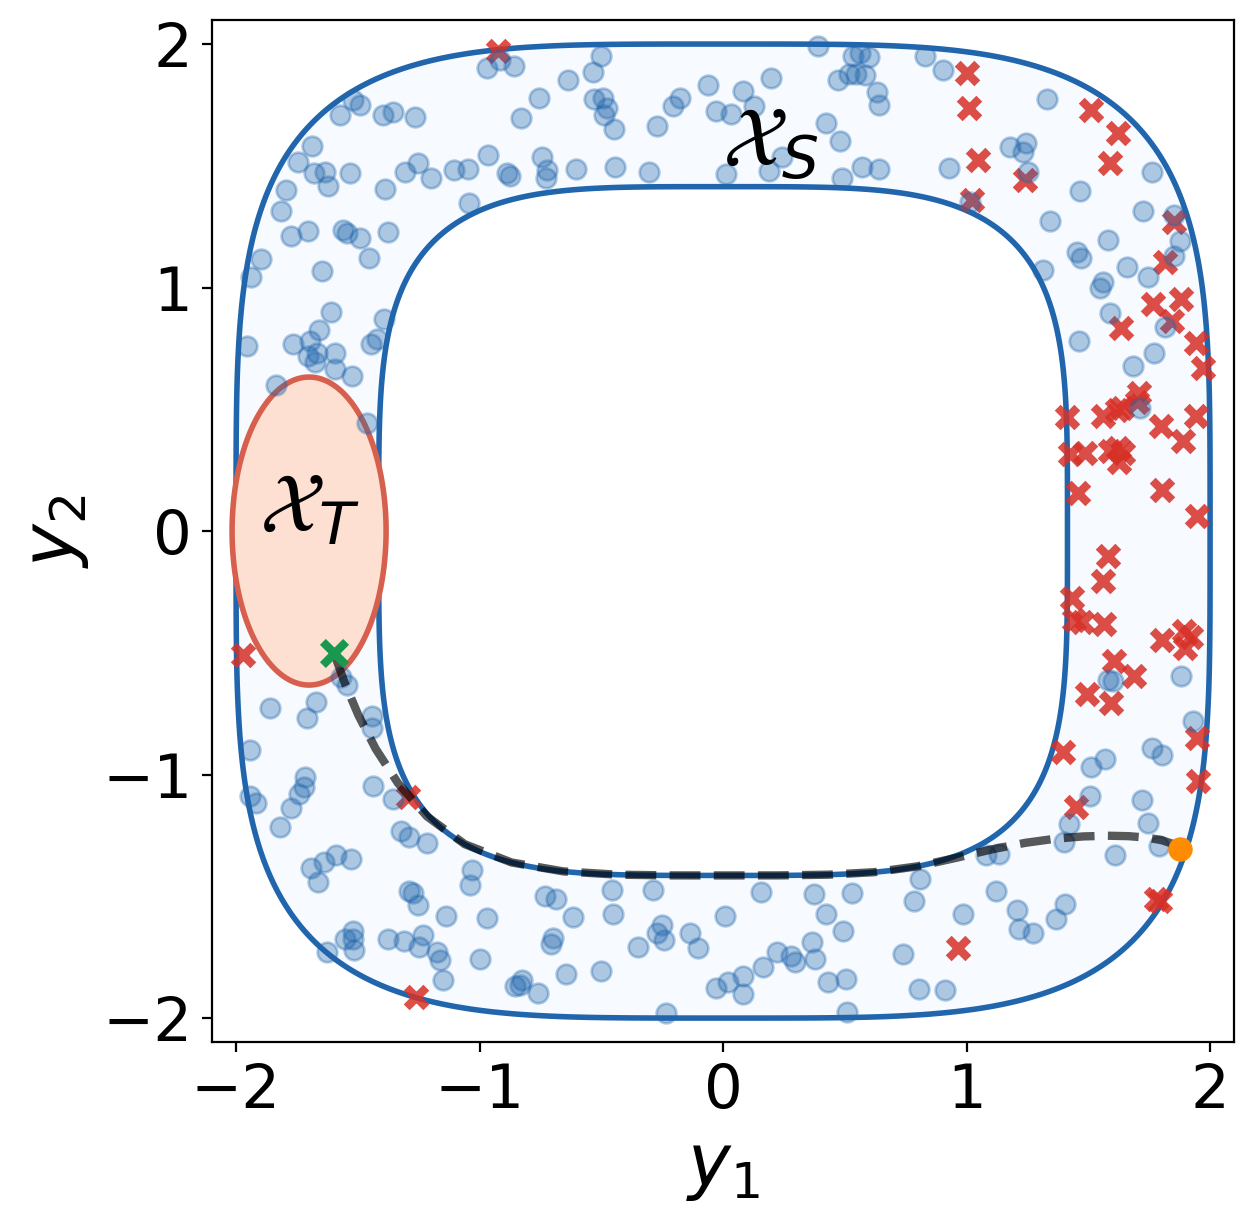

saved fig_dubins_vanilla.png (success 241/300)


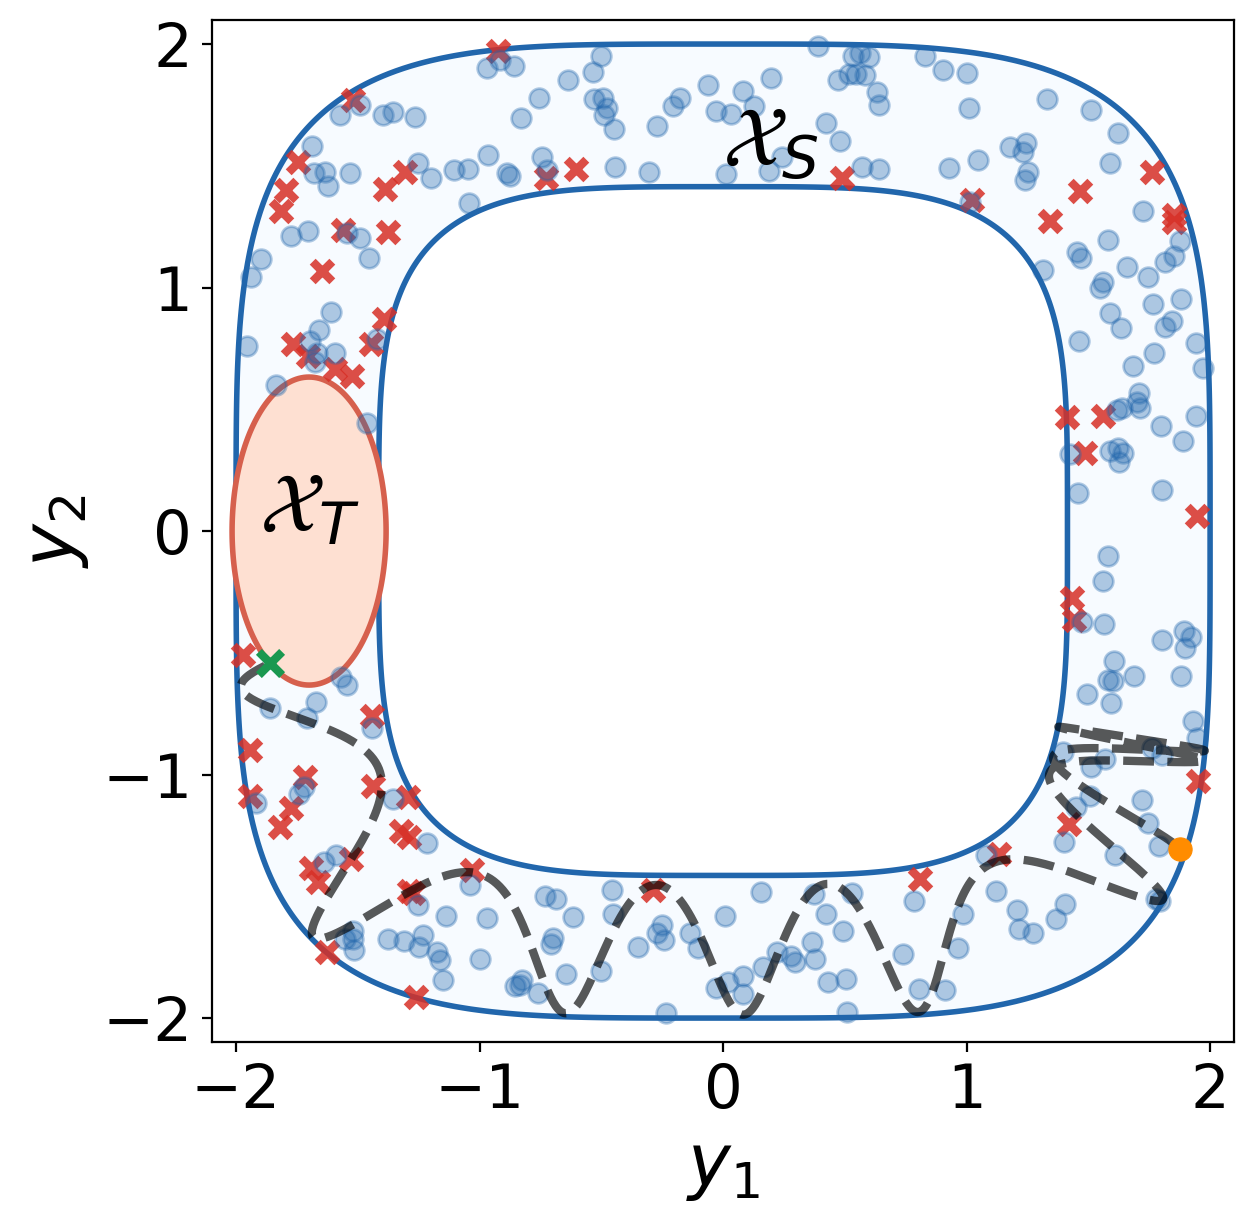

saved fig_dubins_uncon.png (success 245/300)


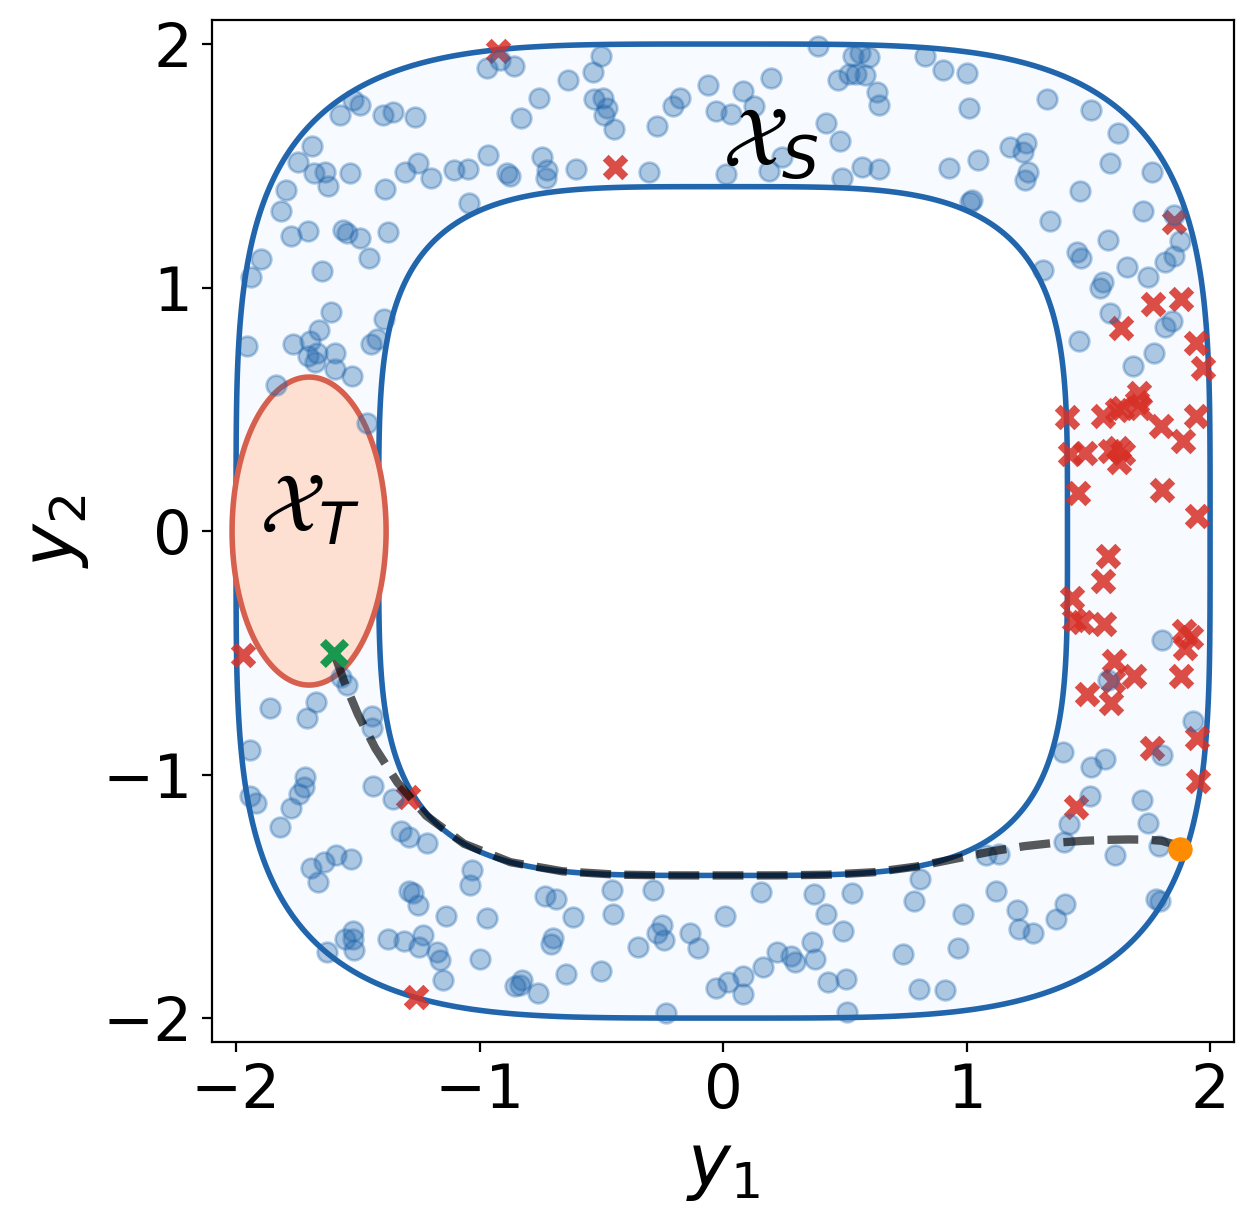

saved fig_dubins_rampc.png (success 251/300)


In [92]:
# y-space set grids
g = np.linspace(-2.1, 2.1, 400)
G1, G2 = np.meshgrid(g, g)
Zs = safe_y_f(G1, G2)
Zt = target_y_f(G1, G2)
px = 1 / plt.rcParams["figure.dpi"]
FS_P = 30

FILE = {
    "Vanilla MPC": "fig_dubins_vanilla.png",
    "Uncon. reach-avoid": "fig_dubins_uncon.png",
    "RA-MPC (ours)": "fig_dubins_rampc.png",
}


def draw_sets(ax):
    ax.contourf(G1, G2, Zs, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1)
    ax.contour(G1, G2, Zs, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
    ax.contourf(
        G1, G2, Zt, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
    )
    ax.contour(G1, G2, Zt, levels=[0], colors=["#d6604d"], linewidths=2, zorder=4)


# ── k1(y) vector fields (output space) for the reach-avoid methods ──
n_vf = 30
y1_vf = np.linspace(-2.1, 2.1, n_vf)
y2_vf = np.linspace(-2.1, 2.1, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(y1_vf, y2_vf)


def _k1_field(k1_opt):
    f = sp.lambdify([y1, y2], list(k1_opt), "numpy")

    def ev(Yg1, Yg2):
        vals = f(Yg1, Yg2)
        U = np.broadcast_to(np.asarray(vals[0], float), Yg1.shape).astype(float)
        V = np.broadcast_to(np.asarray(vals[1], float), Yg1.shape).astype(float)
        return U, V

    return ev


K1_FIELD = {
    "Uncon. reach-avoid": _k1_field(unc_mod.k1_opt),
    "RA-MPC (ours)": _k1_field(ra_mod.k1_opt),
}


for method in ["Vanilla MPC", "Uncon. reach-avoid", "RA-MPC (ours)"]:
    mask = succ[method]
    ns = int(mask.sum())
    tt, uu, xx = tj[method]
    Yt = np.array(hx_f(*xx.T)).reshape(2, -1)
    fig, ax = plt.subplots(figsize=(650 * px, 600 * px), layout="constrained")
    fig.set_dpi(200)
    # k1(y) vector field behind the sets (reach-avoid methods only)
    # if method in K1_FIELD:
    #     Uk, Vk = K1_FIELD[method](VF_Y1, VF_Y2)
    #     ax.streamplot(
    #         y1_vf,
    #         y2_vf,
    #         Uk,
    #         Vk,
    #         color=BetterColor.gray0(0.45),
    #         linewidth=0.9,
    #         density=0.9,
    #         arrowsize=0.9,
    #         zorder=1,
    #     )
    draw_sets(ax)
    ax.scatter(
        Y0[0, ~mask],
        Y0[1, ~mask],
        s=50,
        color="#d73027",
        alpha=0.85,
        marker="x",
        linewidths=3,
        label="failure (%d)" % (Ncand - ns),
        zorder=8,
    )
    ax.scatter(
        Y0[0, mask],
        Y0[1, mask],
        s=50,
        color="#2166ac",
        alpha=0.35,
        marker="o",
        label="success (%d)" % ns,
        zorder=9,
    )
    ax.plot(Yt[0], Yt[1], color="black", lw=3, alpha=0.65, linestyle="--", zorder=10)
    ax.scatter(
        Yt[0, 0], Yt[1, 0], s=70, c=[C_START], marker="o", linewidths=0.4, zorder=20
    )
    ax.scatter(
        Yt[0, -1], Yt[1, -1], s=70, c=[C_END], marker="x", linewidths=3, zorder=20
    )
    fs = 30
    ax.text(0, 1.5, r"$\mathcal{X}_S$", zorder=100, fontsize=fs)
    ax.text(-1.9, 0, r"$\mathcal{X}_T$", zorder=1000, fontsize=fs)
    ax.set_xlabel("$y_1$", fontsize=FS_P - 4)
    ax.set_ylabel("$y_2$", fontsize=FS_P - 4)
    ax.xaxis.set_tick_params(labelsize=22)
    ax.yaxis.set_tick_params(labelsize=22)
    ax.set_xlim(-2.1, 2.1)
    ax.set_ylim(-2.1, 2.1)
    ax.set_aspect("equal")
    # ax.legend(fontsize=16, loc="upper right")
    fig.savefig(os.path.join(REV_DATA, FILE[method]), dpi=200)
    plt.show()
    print("saved", FILE[method], "(success %d/%d)" % (ns, Ncand))

## §6 — Comparison figure (RA-MPC sweep + control inputs)

Vertical 3-row stack, same figure size as the per-method panels so it slots in
as the 4th plot of a 4-across layout. Top: RA-MPC success rate vs sampling time
$T_s$. Bottom two: control channels $\omega, a$ for the **shared $x_0$**,
comparing the unconstrained controller (continuous, blue) and RA-MPC (ZOH step,
purple) against the $\pm$bounds (style follows the unconstrained notebook
cell 11). Saved as `fig_dubins_compare.png`.


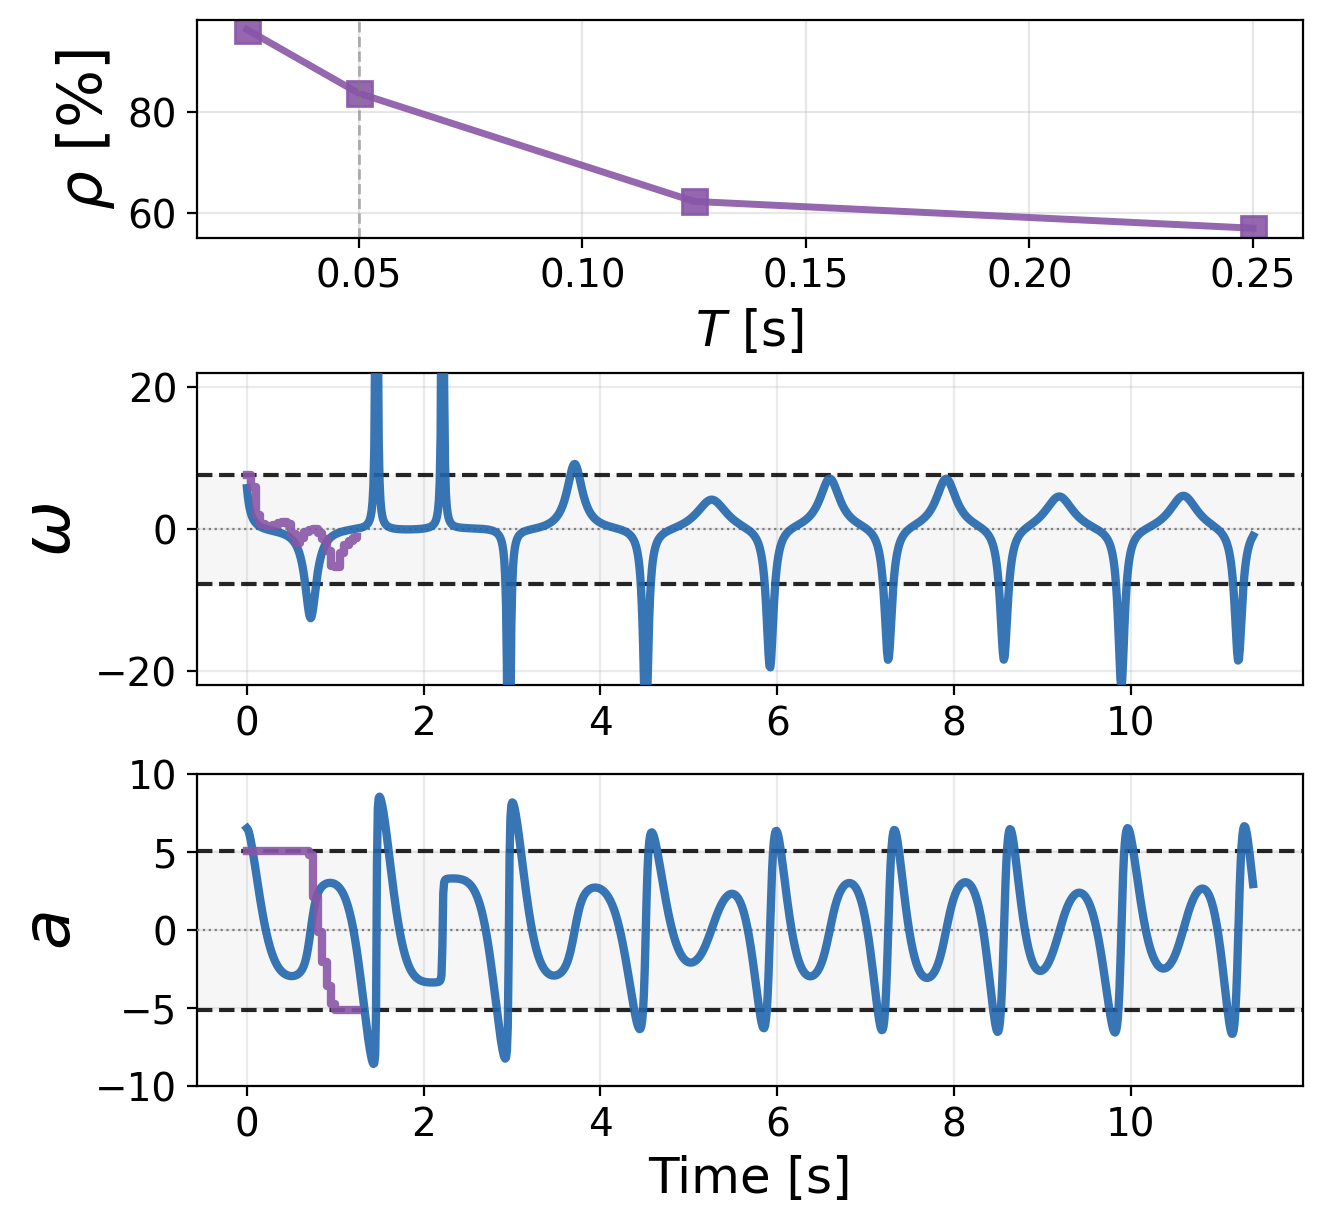

saved fig_dubins_compare.png


In [93]:
summary = pd.read_csv(os.path.join(REV_DATA, "dubins_sweep_summary.csv"))
tu, uu_u, _xu = tj["Uncon. reach-avoid"]  # continuous uncon control along dense path
tr, uu_r, _xr = tj["RA-MPC (ours)"]  # RA-MPC ZOH control
px = 1 / plt.rcParams["figure.dpi"]
FS_C = 24

fig, (axR, axW, axA) = plt.subplots(
    3,
    1,
    figsize=(650 * px, 600 * px),
    layout="constrained",
    gridspec_kw={"height_ratios": [0.7, 1.0, 1.0]},
)
fig.set_dpi(200)

# --- top: RA-MPC success rate vs sampling time ---
sub = summary[summary["method"] == "RA-MPC (ours)"].sort_values("dt_mpc")
axR.plot(
    sub["dt_mpc"],
    sub["success_rate"],
    color="#8856a7",
    marker="s",
    lw=2.5,
    ms=9,
    alpha=0.9,
    label="RA-MPC (ours)",
)
axR.axvline(BASE_DT, color="gray", lw=1, ls="--", alpha=0.6)
axR.set_xlabel("$T$ [s]", fontsize=FS_C - 6)
axR.set_ylabel(r"$\rho$ [%]", fontsize=FS_C - 2)
axR.xaxis.set_tick_params(labelsize=14)
axR.yaxis.set_tick_params(labelsize=14)
axR.grid(True, alpha=0.3)
# axR.legend(fontsize=12, loc="lower left")

# --- bottom two: control comparison (shared x0): uncon continuous vs RA-MPC step ---
YLIM = {0: (-22, 22), 1: (-10, 10)}
for ax, ch, ub, lbl in zip((axW, axA), (0, 1), U_MAX, (r"$\omega$", r"$a$")):
    ax.axhspan(-ub, ub, color="#f0f0f0", alpha=0.6, zorder=0)
    ax.axhline(ub, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(-ub, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(0, color="gray", lw=0.8, ls=":", zorder=4)
    ax.plot(
        tu,
        uu_u[:, ch],
        color="#2166ac",
        lw=3,
        alpha=0.9,
        zorder=10,
        label="unconstrained",
    )
    ax.step(
        tr[:-1],
        uu_r[:, ch],
        where="post",
        color="#8856a7",
        lw=3,
        alpha=0.9,
        zorder=10,
        label="RA-MPC (ours)",
    )
    ax.set_ylabel(lbl, fontsize=FS_C)
    ax.set_ylim(*YLIM[ch])
    ax.xaxis.set_tick_params(labelsize=14)
    ax.yaxis.set_tick_params(labelsize=14)
    ax.grid(True, alpha=0.25)
axA.set_xlabel("Time [s]", fontsize=FS_C - 6)
# axW.legend(fontsize=11, loc="upper right", ncol=1)
fig.savefig(os.path.join(REV_DATA, "fig_dubins_compare.png"), dpi=200)
plt.show()
print("saved fig_dubins_compare.png")